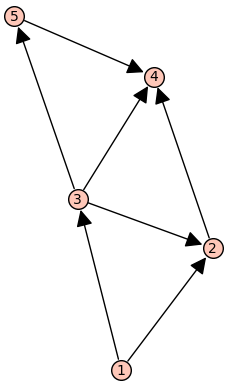

In [4]:
g = DiGraph(weighted = True)
g.add_edges([(1, 2, 8), (1,3,2), (2,4,1), (3,2,5), (3,4, 11), (3,5,1), (5, 4, 9)])
g.show()

In [5]:
M = g.weighted_adjacency_matrix()
print(M)

[ 0  8  2  0  0]
[ 0  0  0  1  0]
[ 0  5  0 11  1]
[ 0  0  0  0  0]
[ 0  0  0  9  0]


In [6]:
g.edges()

[(1, 2, 8), (1, 3, 2), (2, 4, 1), (3, 2, 5), (3, 4, 11), (3, 5, 1), (5, 4, 9)]

In [7]:
print(Infinity > 9999)
print(Infinity + 82 == Infinity)
print(Infinity + 1 > Infinity)
print(Infinity*(-72) == -Infinity)

True
True
False
True


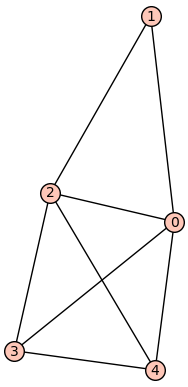

In [28]:

# Il faut ajouter le graphe non-orienté (Pondéré) pour tester l'algo de Djigkstra 
g2 = Graph()
g2.add_edges([(0,1,2), (0,2,4), (0,3,3), (0,4,6), (1,2,7), (2,3,2), (2,4,8), (3,4,1)])
g2.show()


In [ ]:
# Ma matrice de poid M2 (matrice d'adjacence)
M2 = g2.weighted_adjacency_matrix()
print(M2)

[0 2 4 3 6]
[2 0 7 0 0]
[4 7 0 2 8]
[3 0 2 0 1]
[6 0 8 1 0]


# EXERCICE 1: Bellman-Ford (Simplifié)

In [19]:
def Bellman_Ford(M):
    n = M.nrows()                     
    Dist = [Infinity] * n             
    Dist[0] = 0                       

    changement = True                 
    while changement:                 
        changement = False            
        for i in range(n):            
            for j in range(n):        
                poids = M[i][j]
                if poids == 0 and i != j:
                    poids = Infinity  
                if Dist[i] + poids < Dist[j]:
                    Dist[j] = Dist[i] + poids
                    changement = True 
    return Dist

In [29]:
# testons voir si ça marche maintenant ! sur notre matrice de poid orienté où non orienté au début
print(Bellman_Ford(M))    
print(Bellman_Ford(M2))  


[0, 7, 2, 8, 3]
[0, 2, 4, 3, 4]


# EXERCICE 2 : dijkstra

In [ ]:
def dijkstra(M):
    n = M.nrows()                     
    Dist = [Infinity] * n             
    Dist[0] = 0                       
    marquage = [0] * n                

    while 0 in marquage:              
        mini = Infinity
        # là j'ai decidé de mettre une valeur negative pour sortir dans le graphe !
        i = -5
        for k in range(n):
            if marquage[k] == 0 and Dist[k] < mini:
                mini = Dist[k]
                i = k

        if i == -5:                   
            break

        marquage[i] = 1               

        for j in range(n):            
            if marquage[j] == 0:
                poids = M[i][j]
                if poids == 0 and i != j:
                    poids = Infinity  
                if Dist[i] + poids < Dist[j]:
                    Dist[j] = Dist[i] + poids
    return Dist


In [20]:
print(dijkstra(M))    
print(dijkstra(M2)) 

[0, 7, 2, 8, 3]
[0, 2, 4, 3, 4]


# Bonus : Dijkstra avec affichage du chemin

In [25]:
def dijkstra_chemin(M):
    n = M.nrows()
    Dist = [Infinity] * n
    Dist[0] = 0
    marquage = [0] * n
    predecesseur = [-1] * n           

    while 0 in marquage:
        mini = Infinity
        i = -5
        for k in range(n):
            if marquage[k] == 0 and Dist[k] < mini:
                mini = Dist[k]
                i = k

        if i == -5:
            break

        marquage[i] = 1

        for j in range(n):
            if marquage[j] == 0:
                poids = M[i][j]
                if poids == 0 and i != j:
                    poids = Infinity
                if Dist[i] + poids < Dist[j]:
                    Dist[j] = Dist[i] + poids
                    predecesseur[j] = i      

    
    for sommet in range(n):
        chemin = []
        s = sommet
        while s != -1:
            chemin = [s] + chemin    
            s = predecesseur[s]
        print("Sommet", sommet, ": distance =", Dist[sommet], ", chemin =", chemin)

    return Dist


In [27]:
# Testons sur la matrice M
dijkstra_chemin(M)


Sommet 0 : distance = 0 , chemin = [0]
Sommet 1 : distance = 7 , chemin = [0, 2, 1]
Sommet 2 : distance = 2 , chemin = [0, 2]
Sommet 3 : distance = 8 , chemin = [0, 2, 1, 3]
Sommet 4 : distance = 3 , chemin = [0, 2, 4]


[0, 7, 2, 8, 3]